# 🎾 Padel Analytics — Time Series Forecasting
## Forecasting Monthly Match Views & Interactions

**Objective:** Forecast monthly padel match viewership and interactions using historical match data.
This metric is critical for sponsors and broadcasters to plan investments and media strategies.

**Sections covered:**
- F1 — Data extraction & preparation
- F2 — Stationarity analysis (ADF/KPSS), decomposition
- F3 — Model 1: ARIMA
- F4 — Model 2: SARIMA
- F5 — Model 3: Prophet
- F6 — Model 4: XGBoost (Time Series)
- F7 — Model comparison: MAPE, RMSE, MAE
- F8 — Visualizations & business insights

---
## 📦 CELL 1 — Install Required Libraries

In [7]:
pip install pyodbc pandas numpy matplotlib seaborn statsmodels prophet xgboost scikit-learn pmdarima

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 3.1 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/12.1 MB 3.1 MB/s eta 0:00:04
   ------ --------------------------------- 2.1/12.1 MB 3.5 MB/s eta 0:00:03
   --------- ------------------------------ 2.9/12.1 MB 3.8 MB/s eta 0:00:03
   ------------- -------------------------- 4.2/12.1 MB 4.2 MB/s eta 0:00:02
   ------------------ --------------------- 5.5/12.1 MB 4.6 MB/s eta 0:00:02
   ----------------------- ---------------- 7.1/12.1 MB 5.0 MB/s eta 0:00:01
   ---------------------------- ----------- 8.7/12.1 MB 5.4 MB/s eta 0:00:01
   ------------------------------------ --- 11.0/12.1 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 6.3 MB/s  0:00:01
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 14.4 MB/s  0:00:00
   ---------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 🔌 CELL 2 — Import Libraries

In [8]:
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Stats & Time Series
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm

# Prophet
from prophet import Prophet

# XGBoost
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

# Display settings
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.style.use('seaborn-v0_8-whitegrid')

print('✅ All libraries imported successfully!')

Importing plotly failed. Interactive plots will not work.


✅ All libraries imported successfully!


---
## 🗄️ CELL 3 — Connect to SQL Server & Extract Data

> ⚠️ **ACTION REQUIRED:** Replace `YOUR_SERVER_NAME` with your actual server name from SSMS (shown at the top when you connect)

In [29]:
# ============================================================
# 🔧 CONFIGURATION — Edit this block
# ============================================================
SERVER   = r'DESKTOP-QJ70MNR\MSSQLSERVER1'   # e.g. 'localhost' or 'DESKTOP-ABC\SQLEXPRESS'
DATABASE = 'DW_padel'
# ============================================================

conn_str = (
    f'DRIVER={{SQL Server}};'
    f'SERVER={SERVER};'
    f'DATABASE={DATABASE};'
    f'Trusted_Connection=yes;'
)

try:
    conn = pyodbc.connect(conn_str)
    print('✅ Connected to SQL Server successfully!')
except Exception as e:
    print(f'❌ Connection failed: {e}')
    print('👉 Try changing SERVER to: localhost  OR  localhost\\SQLEXPRESS')

✅ Connected to SQL Server successfully!


---
## 📥 CELL 4 — Load & Merge Data

In [30]:
# Load FACT_MATCHS
query_fact = """
    SELECT 
        f.date_key,
        f.views,
        f.interactions,
        f.tournament_id
    FROM [DW_padel].[dbo].[FACT_MATCHS] f
    WHERE f.views IS NOT NULL
"""

# Load dim_date
query_date = """
    SELECT 
        date_key,
        full_date,
        annee,
        mois,
        nom_mois,
        trimestre
    FROM [DW_padel].[dbo].[dim_date]
"""

df_fact = pd.read_sql(query_fact, conn)
df_date = pd.read_sql(query_date, conn)

print(f'✅ FACT_MATCHS loaded: {df_fact.shape[0]} rows')
print(f'✅ dim_date loaded:    {df_date.shape[0]} rows')

df_fact.head()

✅ FACT_MATCHS loaded: 2831 rows
✅ dim_date loaded:    35000 rows


,date_key,views,interactions,tournament_id
0,16847,181683,9047,1
1,16846,166165,5234,1
2,16846,159464,5834,1
3,16846,165574,6834,1
4,16845,103135,4242,1


---
## 🔀 CELL 5 — Merge & Aggregate to Monthly Time Series

In [31]:
# Merge fact with date dimension
df = df_fact.merge(df_date, on='date_key', how='left')

# Parse full_date
df['full_date'] = pd.to_datetime(df['full_date'])

# Create year-month period
df['year_month'] = df['full_date'].dt.to_period('M')

# Aggregate monthly
monthly = df.groupby('year_month').agg(
    total_views        = ('views', 'sum'),
    total_interactions = ('interactions', 'sum'),
    match_count        = ('date_key', 'count')
).reset_index()

monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()
monthly = monthly.sort_values('year_month_dt').reset_index(drop=True)

print(f'✅ Monthly time series: {len(monthly)} months')
print(f'   Date range: {monthly["year_month_dt"].min()} → {monthly["year_month_dt"].max()}')
monthly.head(10)

✅ Monthly time series: 28 months
   Date range: 2023-02-01 00:00:00 → 2026-02-01 00:00:00


,year_month,total_views,total_interactions,match_count,year_month_dt
0,2023-02,1348867,39284,23,2023-02-01
1,2023-03,2450509,80647,29,2023-03-01
2,2023-07,11379032,367710,147,2023-07-01
3,2023-08,3448935,108919,45,2023-08-01
4,2023-09,2698302,93678,25,2023-09-01
5,2023-12,5024621,160269,62,2023-12-01
6,2024-02,4707890,145769,63,2024-02-01
7,2024-03,12491104,420460,146,2024-03-01
8,2024-04,4237700,142139,49,2024-04-01
9,2024-05,12552805,403935,158,2024-05-01


---
## 📊 CELL 6 — Exploratory Visualization

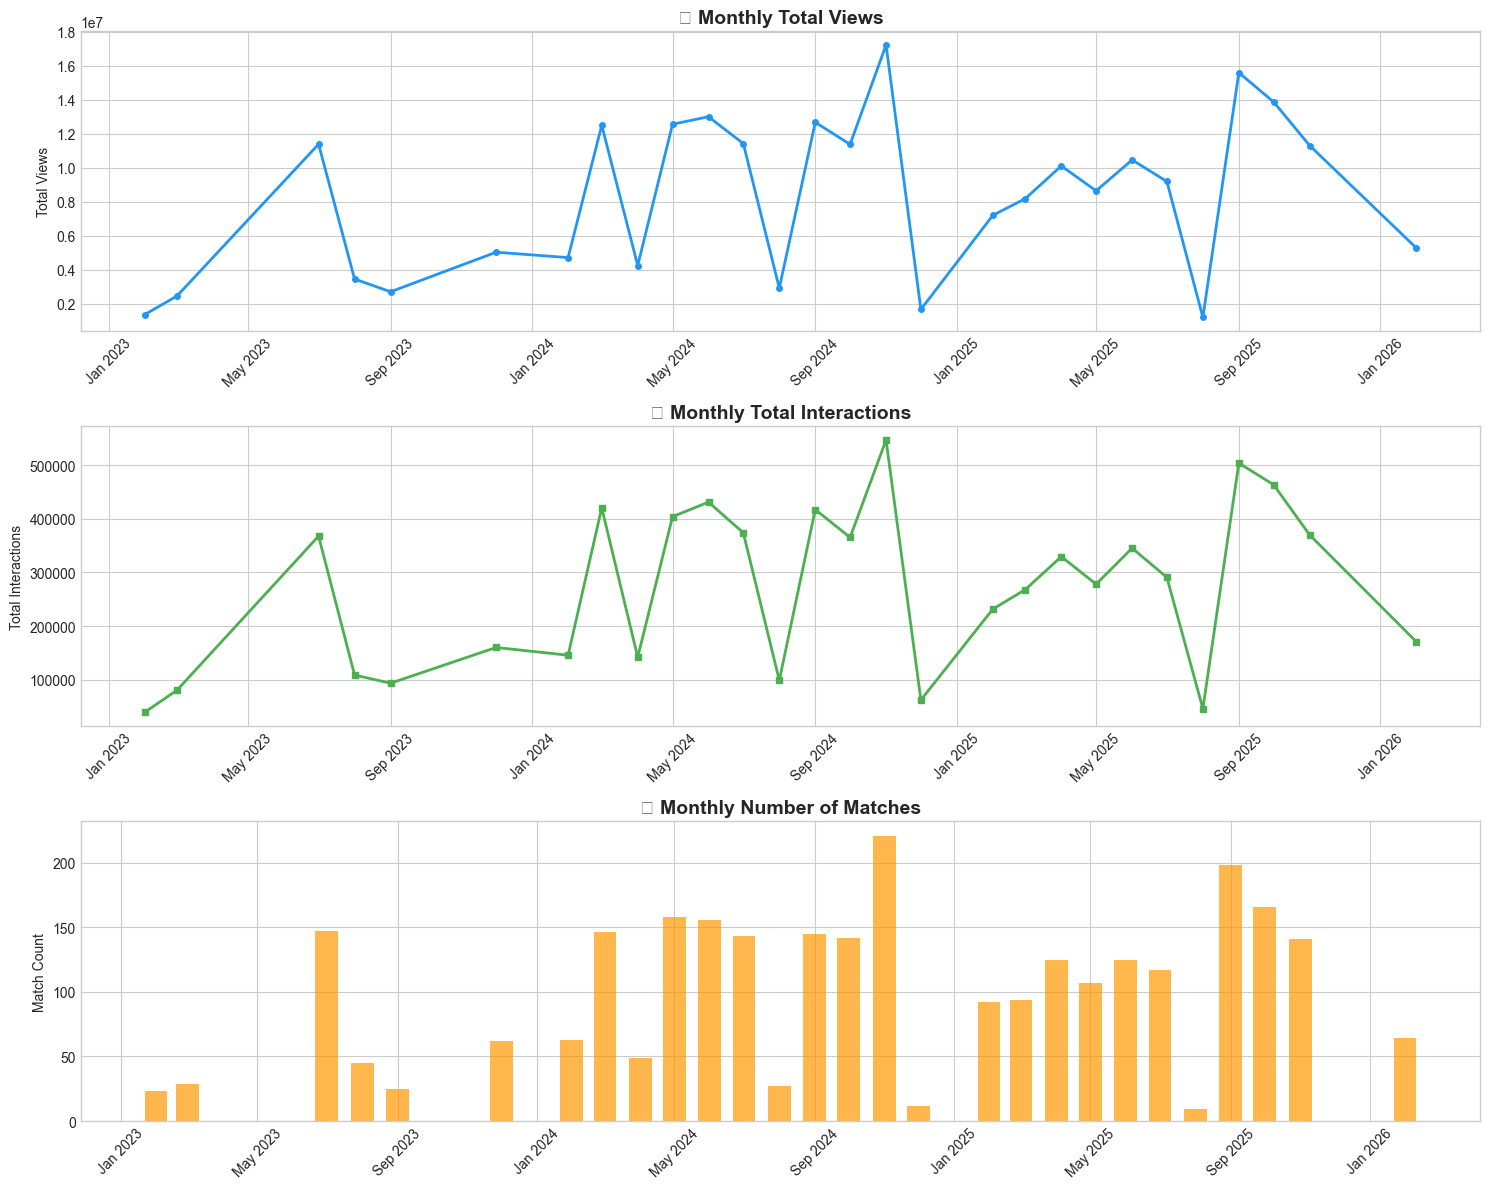

✅ Plot saved as 01_exploratory_plots.png


In [32]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Views
axes[0].plot(monthly['year_month_dt'], monthly['total_views'], color='#2196F3', linewidth=2, marker='o', markersize=4)
axes[0].set_title('📈 Monthly Total Views', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Views')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Interactions
axes[1].plot(monthly['year_month_dt'], monthly['total_interactions'], color='#4CAF50', linewidth=2, marker='s', markersize=4)
axes[1].set_title('💬 Monthly Total Interactions', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Interactions')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

# Match count
axes[2].bar(monthly['year_month_dt'], monthly['match_count'], color='#FF9800', alpha=0.7, width=20)
axes[2].set_title('🎾 Monthly Number of Matches', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Match Count')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('01_exploratory_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved as 01_exploratory_plots.png')

---
## 🎯 CELL 7 — Define Target Series

We will forecast **total_views** as our primary target.

In [34]:
# 1. On s'assure que 'year_month_dt' est bien au format datetime
monthly['year_month_dt'] = pd.to_datetime(monthly['year_month_dt'])

# 2. On définit l'index
ts = monthly.set_index('year_month_dt')['total_views'].copy()

# 3. FIX CRUCIAL : On ré-échantillonne par mois (Month Start) 
# .sum() regroupe les données et .fillna(0) évite les valeurs manquantes (NaN)
ts = ts.resample('MS').sum().fillna(0)

# 4. Maintenant on peut fixer la fréquence sans erreur
ts.index.freq = 'MS'

print('📌 Target: Monthly Total Views (Fixed)')
print(f'   Observations : {len(ts)}')
print(f'   Min  : {ts.min():,.0f}')
print(f'   Max  : {ts.max():,.0f}')
print(f'   Mean : {ts.mean():,.0f}')
print(f'   Freq : {ts.index.freqstr}')

# Affichage des premières lignes pour vérification
display(ts.to_frame().head())

📌 Target: Monthly Total Views (Fixed)
   Observations : 37
   Min  : 0
   Max  : 17,216,601
   Mean : 6,257,466
   Freq : MS


,total_views
year_month_dt,
2023-02-01,1348867
2023-03-01,2450509
2023-04-01,0
2023-05-01,0
2023-06-01,0


---
## 🔬 CELL 8 — Stationarity Analysis
### ADF Test (Augmented Dickey-Fuller) & KPSS Test

In [35]:
def run_adf_test(series, label='Series'):
    print(f'\n{'='*55}')
    print(f'  ADF Test — {label}')
    print(f'{'='*55}')
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    for key, val in result[4].items():
        print(f'  Critical Value ({key}): {val:.4f}')
    if result[1] < 0.05:
        print('  ✅ STATIONARY (reject H0 — no unit root)')
    else:
        print('  ❌ NON-STATIONARY (fail to reject H0 — unit root exists)')

def run_kpss_test(series, label='Series'):
    print(f'\n{'='*55}')
    print(f'  KPSS Test — {label}')
    print(f'{'='*55}')
    result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'  KPSS Statistic : {result[0]:.4f}')
    print(f'  p-value        : {result[1]:.4f}')
    for key, val in result[3].items():
        print(f'  Critical Value ({key}): {val:.4f}')
    if result[1] > 0.05:
        print('  ✅ STATIONARY (fail to reject H0)')
    else:
        print('  ❌ NON-STATIONARY (reject H0)')

# Test original series
run_adf_test(ts, 'Original Series')
run_kpss_test(ts, 'Original Series')

# Test first difference
ts_diff = ts.diff().dropna()
run_adf_test(ts_diff, 'First Difference')
run_kpss_test(ts_diff, 'First Difference')


  ADF Test — Original Series
  ADF Statistic : -4.2517
  p-value       : 0.0005
  Critical Value (1%): -3.6267
  Critical Value (5%): -2.9460
  Critical Value (10%): -2.6117
  ✅ STATIONARY (reject H0 — no unit root)

  KPSS Test — Original Series
  KPSS Statistic : 0.4207
  p-value        : 0.0682
  Critical Value (10%): 0.3470
  Critical Value (5%): 0.4630
  Critical Value (2.5%): 0.5740
  Critical Value (1%): 0.7390
  ✅ STATIONARY (fail to reject H0)

  ADF Test — First Difference
  ADF Statistic : -5.9042
  p-value       : 0.0000
  Critical Value (1%): -3.6461
  Critical Value (5%): -2.9541
  Critical Value (10%): -2.6160
  ✅ STATIONARY (reject H0 — no unit root)

  KPSS Test — First Difference
  KPSS Statistic : 0.2358
  p-value        : 0.1000
  Critical Value (10%): 0.3470
  Critical Value (5%): 0.4630
  Critical Value (2.5%): 0.5740
  Critical Value (1%): 0.7390
  ✅ STATIONARY (fail to reject H0)


---
## 📉 CELL 9 — Time Series Decomposition

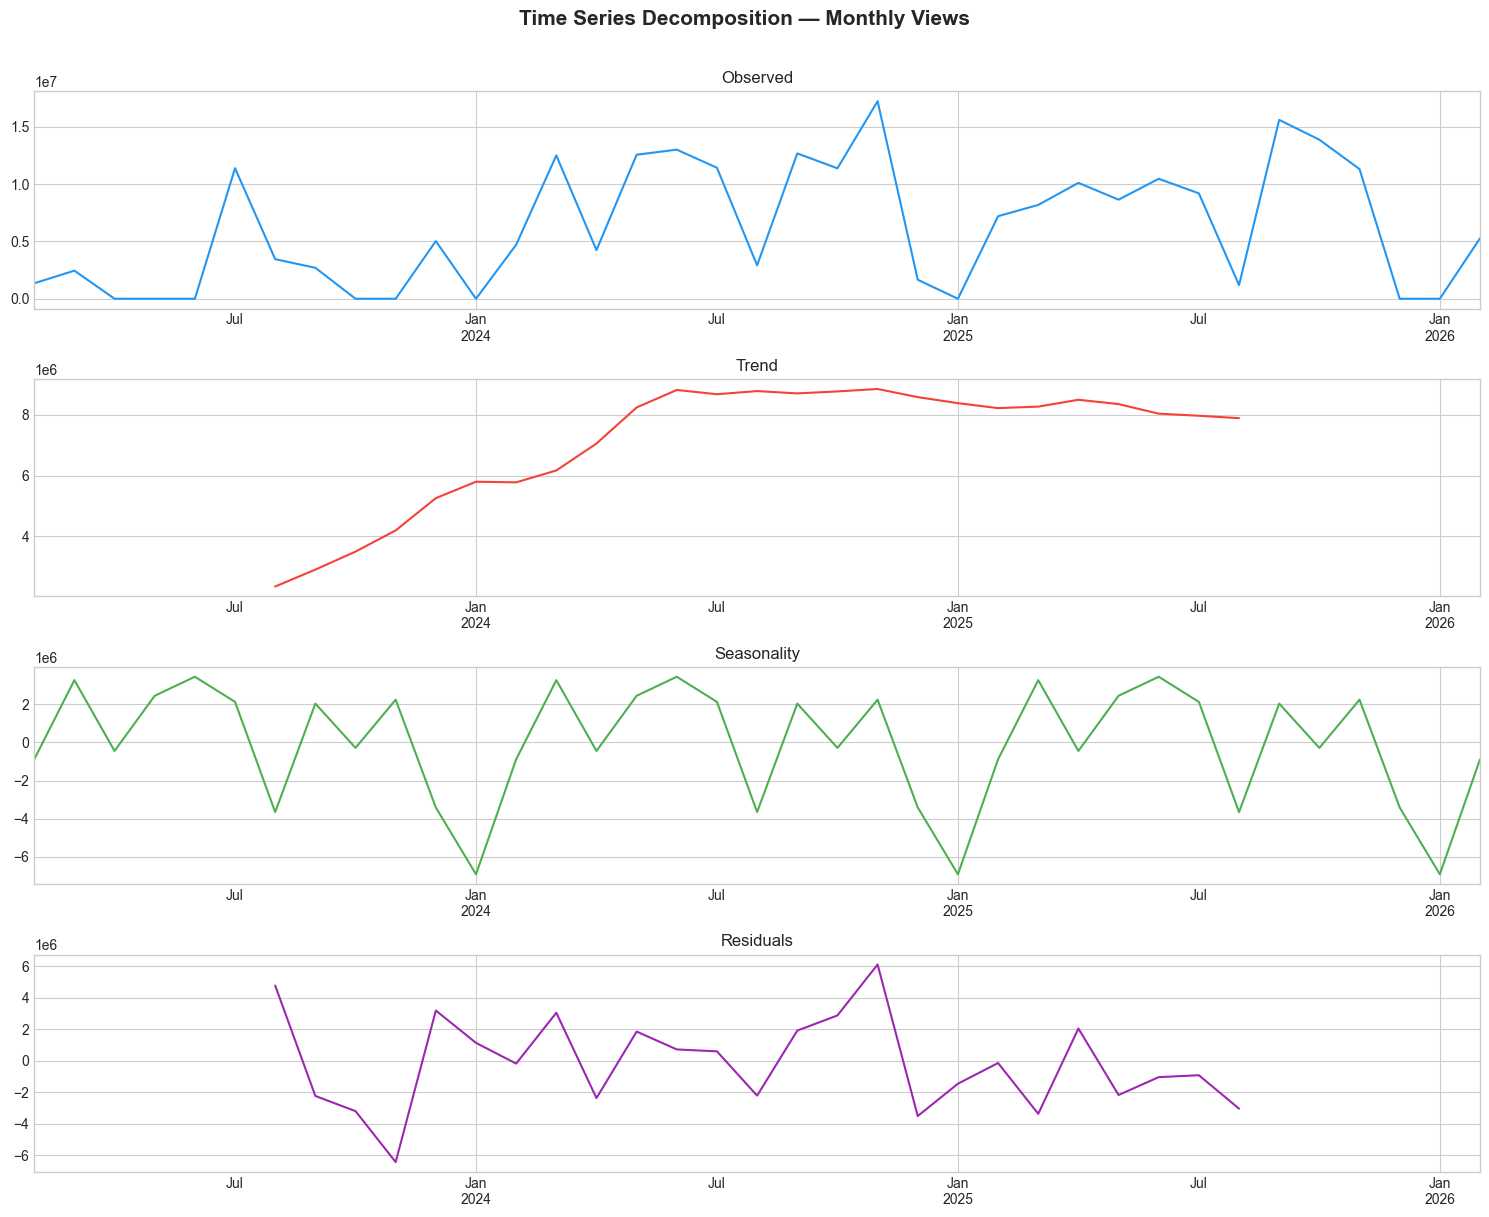

✅ Decomposition plot saved as 02_decomposition.png


In [36]:
# Decompose (additive model)
# Note: needs at least 2 full periods — if series is short, period=6 is used
period = 12 if len(ts) >= 24 else 6

decomp = seasonal_decompose(ts, model='additive', period=period)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))

decomp.observed.plot(ax=axes[0], color='#2196F3', title='Observed')
decomp.trend.plot(ax=axes[1], color='#F44336', title='Trend')
decomp.seasonal.plot(ax=axes[2], color='#4CAF50', title='Seasonality')
decomp.resid.plot(ax=axes[3], color='#9C27B0', title='Residuals')

for ax in axes:
    ax.set_xlabel('')

plt.suptitle('Time Series Decomposition — Monthly Views', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Decomposition plot saved as 02_decomposition.png')

---
## 📊 CELL 10 — ACF & PACF Plots

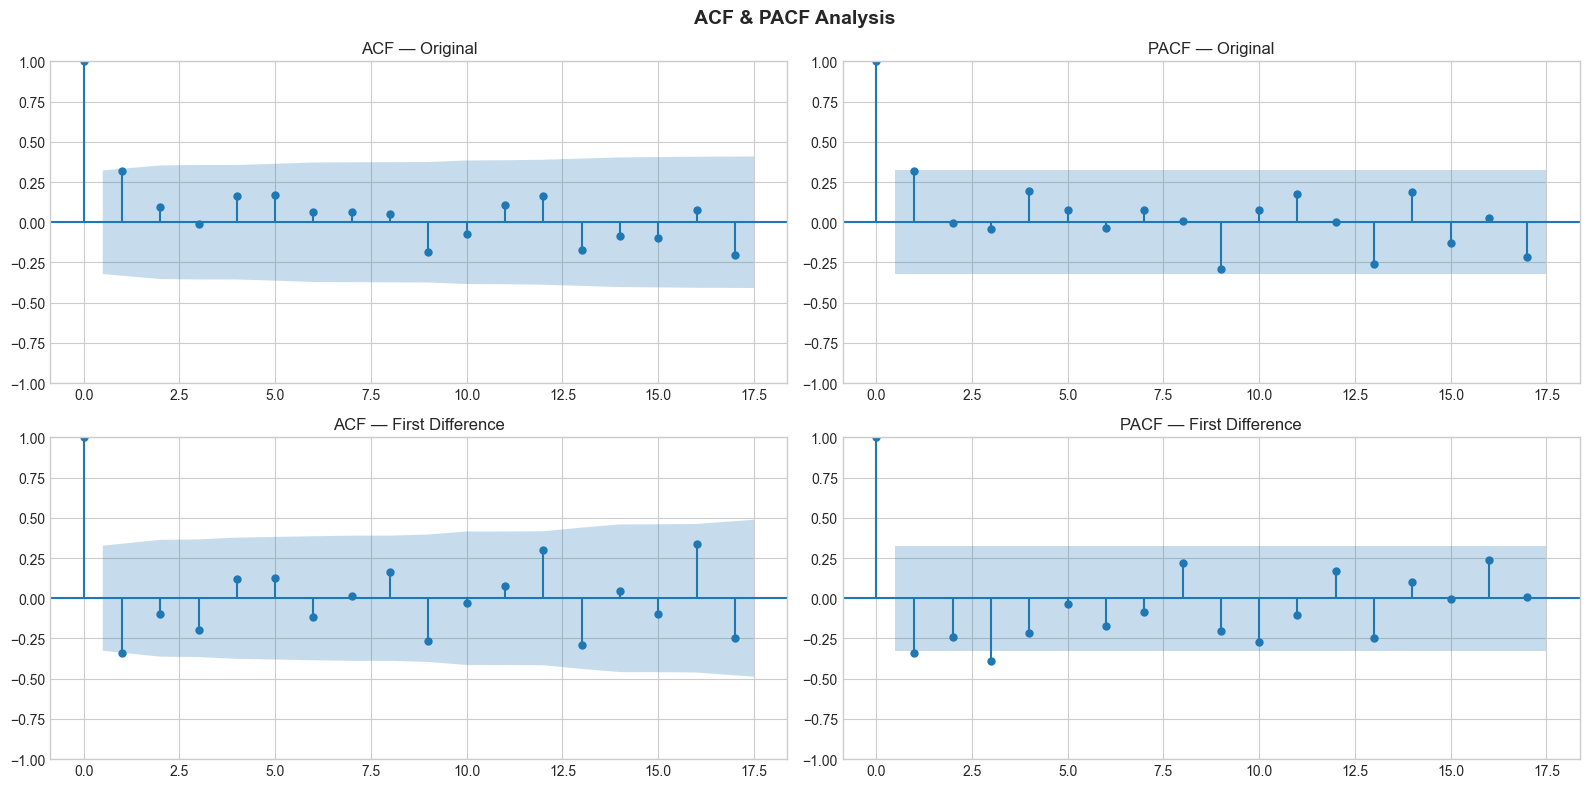

✅ ACF/PACF plot saved as 03_acf_pacf.png


In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

plot_acf(ts.dropna(),  lags=min(20, len(ts)//2 - 1), ax=axes[0, 0], title='ACF — Original')
plot_pacf(ts.dropna(), lags=min(20, len(ts)//2 - 1), ax=axes[0, 1], title='PACF — Original')
plot_acf(ts_diff.dropna(),  lags=min(20, len(ts_diff)//2 - 1), ax=axes[1, 0], title='ACF — First Difference')
plot_pacf(ts_diff.dropna(), lags=min(20, len(ts_diff)//2 - 1), ax=axes[1, 1], title='PACF — First Difference')

plt.suptitle('ACF & PACF Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ ACF/PACF plot saved as 03_acf_pacf.png')

---
## ✂️ CELL 11 — Train / Test Split

✅ Train set: 29 months  (Feb 2023 → Jun 2025)
✅ Test set:  8 months  (Jul 2025 → Feb 2026)


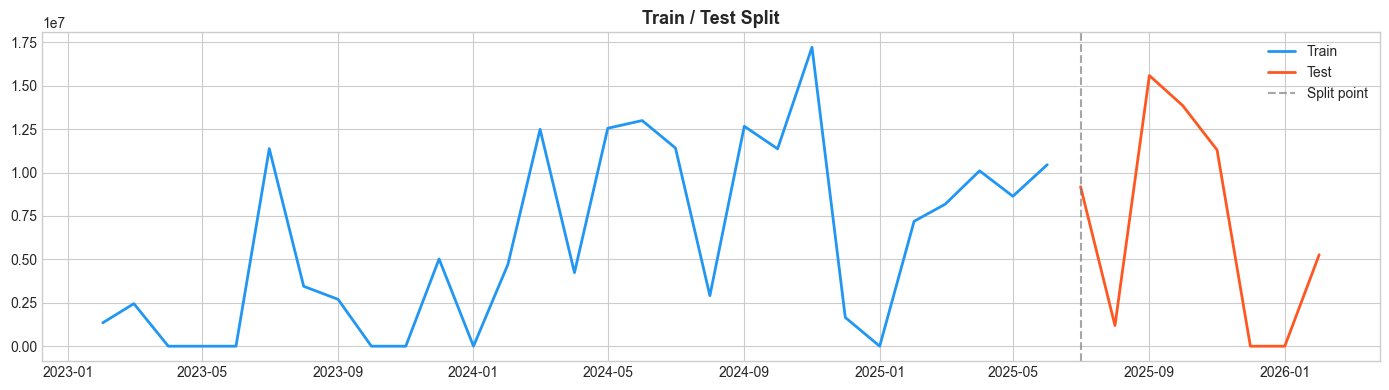

In [38]:
# 80% train — 20% test
split_idx = int(len(ts) * 0.8)
train = ts.iloc[:split_idx]
test  = ts.iloc[split_idx:]

print(f'✅ Train set: {len(train)} months  ({train.index[0].strftime("%b %Y")} → {train.index[-1].strftime("%b %Y")})')
print(f'✅ Test set:  {len(test)} months  ({test.index[0].strftime("%b %Y")} → {test.index[-1].strftime("%b %Y")})')

# Visualize split
plt.figure(figsize=(14, 4))
plt.plot(train.index, train.values, label='Train', color='#2196F3', linewidth=2)
plt.plot(test.index,  test.values,  label='Test',  color='#FF5722', linewidth=2)
plt.axvline(x=test.index[0], color='gray', linestyle='--', alpha=0.7, label='Split point')
plt.title('Train / Test Split', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('04_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📐 CELL 12 — Evaluation Metrics Helper

In [39]:
def evaluate_model(actual, predicted, model_name):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    
    mae  = mean_absolute_error(actual, predicted)
    mse  = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    
    # MAPE — avoid division by zero
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    
    print(f'\n📊 {model_name} — Evaluation Metrics')
    print(f'   MAE  : {mae:>12,.2f}')
    print(f'   RMSE : {rmse:>12,.2f}')
    print(f'   MAPE : {mape:>11.2f}%')
    
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

results = []  # Will store all model results
print('✅ Evaluation function ready!')

✅ Evaluation function ready!


---
## 🤖 CELL 13 — MODEL 1: ARIMA

**Intuition:** ARIMA (AutoRegressive Integrated Moving Average) models the series using its own past values (AR), differences for stationarity (I), and past forecast errors (MA).

**Parameters:** p (AR order), d (differencing), q (MA order)

**Assumptions:** Univariate, stationary after differencing, no seasonality

**Limitations:** Cannot capture strong seasonality, sensitive to outliers

**Why chosen:** Simple, interpretable baseline — good for trending data without strong seasonality

In [40]:
print('🔍 Auto-selecting best ARIMA order using AIC...')

# Auto ARIMA to find best (p, d, q)
auto_arima = pm.auto_arima(
    train,
    seasonal=False,
    stepwise=True,
    information_criterion='aic',
    suppress_warnings=True,
    error_action='ignore'
)

print(f'✅ Best ARIMA order: {auto_arima.order}')
print(auto_arima.summary())

🔍 Auto-selecting best ARIMA order using AIC...
✅ Best ARIMA order: (0, 1, 1)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   29
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -471.898
Date:                Wed, 15 Apr 2026   AIC                            947.797
Time:                        06:32:07   BIC                            950.461
Sample:                    02-01-2023   HQIC                           948.611
                         - 06-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7276      0.150     -4.856      0.000      -1.021      -0.434
sigma2      3.025e+13   5.04e-16   6.01e+28      0.000


📊 ARIMA — Evaluation Metrics
   MAE  : 5,434,976.25
   RMSE : 6,145,788.08
   MAPE :      134.97%


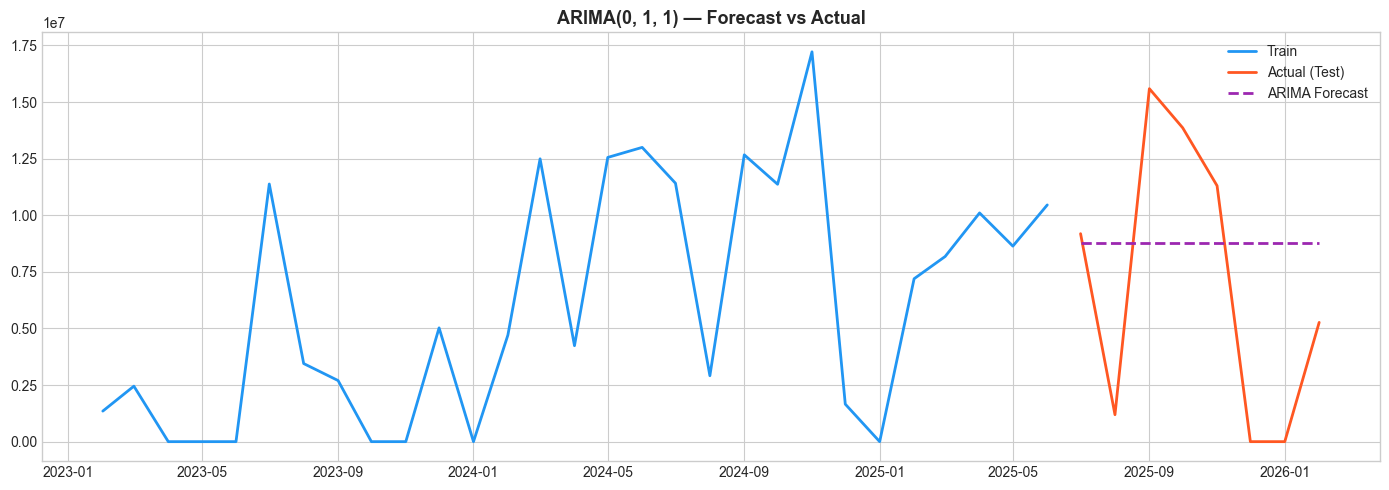

In [41]:
# Fit ARIMA with best order
p, d, q = auto_arima.order

arima_model = ARIMA(train, order=(p, d, q))
arima_fit   = arima_model.fit()

# Forecast
arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast = pd.Series(arima_forecast.values, index=test.index)

# Evaluate
arima_metrics = evaluate_model(test, arima_forecast, 'ARIMA')
results.append(arima_metrics)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values, label='Train', color='#2196F3', linewidth=2)
plt.plot(test.index,  test.values,  label='Actual (Test)', color='#FF5722', linewidth=2)
plt.plot(arima_forecast.index, arima_forecast.values, label='ARIMA Forecast', color='#9C27B0', linewidth=2, linestyle='--')
plt.title(f'ARIMA{auto_arima.order} — Forecast vs Actual', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('05_arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🤖 CELL 14 — MODEL 2: SARIMA

**Intuition:** SARIMA extends ARIMA by adding Seasonal components (P, D, Q, s). It can capture both trend and seasonal patterns.

**Parameters:** (p,d,q) × (P,D,Q,s) where s=12 for monthly data

**Assumptions:** Seasonal stationarity, regular seasonal pattern

**Limitations:** Many parameters to tune, computationally heavier

**Why chosen:** Padel viewership may follow seasonal patterns (more matches in certain months)

In [42]:
print('🔍 Auto-selecting best SARIMA order...')

m = 12 if len(train) >= 24 else 6  # seasonal period

auto_sarima = pm.auto_arima(
    train,
    seasonal=True,
    m=m,
    stepwise=True,
    information_criterion='aic',
    suppress_warnings=True,
    error_action='ignore',
    max_p=3, max_q=3, max_P=2, max_Q=2
)

print(f'✅ Best SARIMA order: {auto_sarima.order} × {auto_sarima.seasonal_order}')
print(auto_sarima.summary())

🔍 Auto-selecting best SARIMA order...
✅ Best SARIMA order: (0, 1, 1) × (0, 0, 0, 12)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   29
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -471.898
Date:                Wed, 15 Apr 2026   AIC                            947.797
Time:                        06:32:50   BIC                            950.461
Sample:                    02-01-2023   HQIC                           948.611
                         - 06-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7276      0.150     -4.856      0.000      -1.021      -0.434
sigma2      3.025e+13   5.04e-16   6.01e+28   


📊 SARIMA — Evaluation Metrics
   MAE  : 5,434,976.25
   RMSE : 6,122,742.25
   MAPE :      133.98%


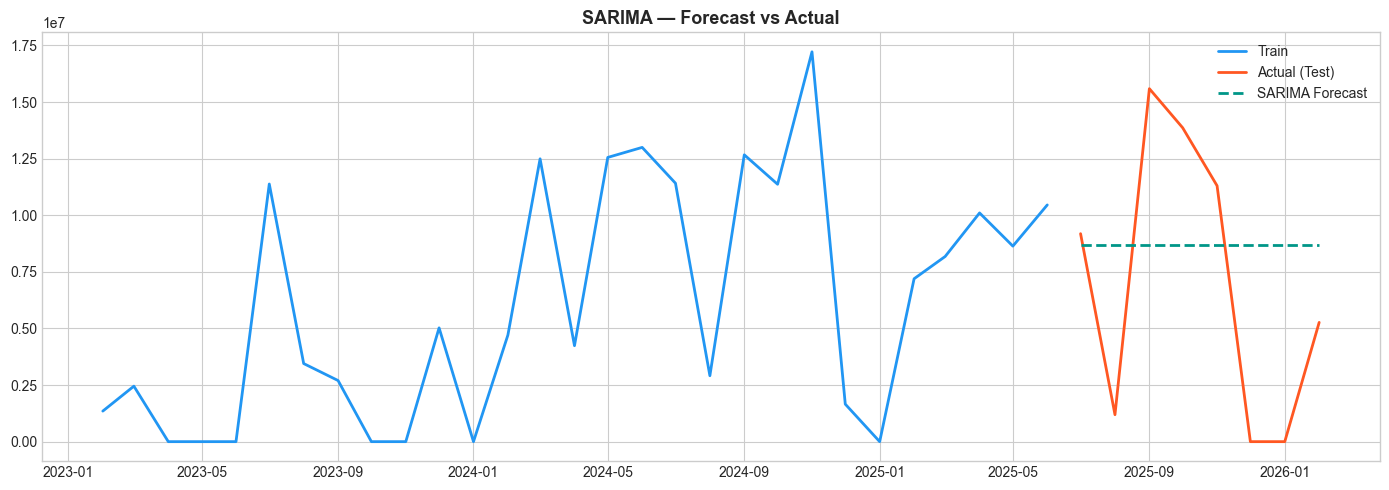

In [43]:
# Fit SARIMA
sarima_model = SARIMAX(
    train,
    order=auto_sarima.order,
    seasonal_order=auto_sarima.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)

# Forecast
sarima_forecast = sarima_fit.forecast(steps=len(test))
sarima_forecast = pd.Series(sarima_forecast.values, index=test.index)

# Evaluate
sarima_metrics = evaluate_model(test, sarima_forecast, 'SARIMA')
results.append(sarima_metrics)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values, label='Train', color='#2196F3', linewidth=2)
plt.plot(test.index,  test.values,  label='Actual (Test)', color='#FF5722', linewidth=2)
plt.plot(sarima_forecast.index, sarima_forecast.values, label='SARIMA Forecast', color='#009688', linewidth=2, linestyle='--')
plt.title(f'SARIMA — Forecast vs Actual', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('06_sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🤖 CELL 15 — MODEL 3: Prophet

**Intuition:** Prophet (by Meta) decomposes the time series into trend + seasonality + holidays. It's robust to missing data and outliers.

**Parameters:** changepoint_prior_scale (trend flexibility), seasonality_mode (additive/multiplicative)

**Assumptions:** Regular seasonality, no need for stationarity

**Limitations:** Less interpretable coefficients, may overfit with small datasets

**Why chosen:** Handles sports seasonality well, easy to add external regressors

06:33:00 - cmdstanpy - INFO - Chain [1] start processing
06:33:01 - cmdstanpy - INFO - Chain [1] done processing



📊 Prophet — Evaluation Metrics
   MAE  : 5,326,610.12
   RMSE : 5,922,525.14
   MAPE :      143.79%


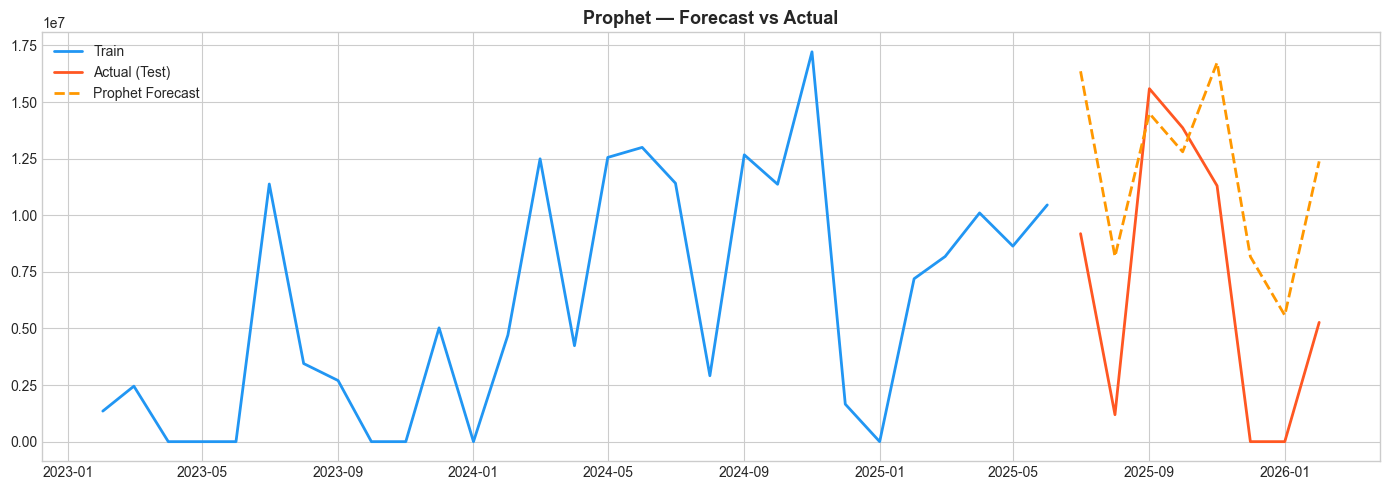

In [44]:
# Prophet requires columns: ds (date) and y (value)
prophet_train = pd.DataFrame({
    'ds': train.index,
    'y' : train.values
})

# Fit Prophet
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_mode='additive'
)
prophet_model.fit(prophet_train)

# Create future dataframe for test period
future = prophet_model.make_future_dataframe(periods=len(test), freq='MS')
prophet_pred = prophet_model.predict(future)

# Extract test predictions
prophet_forecast = prophet_pred.set_index('ds')['yhat'].iloc[-len(test):]
prophet_forecast.index = test.index

# Evaluate
prophet_metrics = evaluate_model(test, prophet_forecast, 'Prophet')
results.append(prophet_metrics)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values, label='Train', color='#2196F3', linewidth=2)
plt.plot(test.index,  test.values,  label='Actual (Test)', color='#FF5722', linewidth=2)
plt.plot(prophet_forecast.index, prophet_forecast.values, label='Prophet Forecast', color='#FF9800', linewidth=2, linestyle='--')
plt.title('Prophet — Forecast vs Actual', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('07_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Prophet Components Plot (trend + seasonality breakdown)
fig = prophet_model.plot_components(prophet_pred)
plt.suptitle('Prophet — Components Breakdown', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('08_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Prophet components saved as 08_prophet_components.png')

---
## 🤖 CELL 16 — MODEL 4: XGBoost (Time Series)

**Intuition:** XGBoost is a gradient boosting algorithm. For time series, we engineer lag features (past values) and date features, turning the forecasting problem into a supervised regression.

**Parameters:** n_estimators, learning_rate, max_depth

**Assumptions:** Relationships captured by lag features, no autocorrelation assumption

**Limitations:** Doesn't extrapolate beyond training range natively, needs careful feature engineering

**Why chosen:** Powerful non-linear model, captures complex patterns, works well with engineered features

In [45]:
def create_lag_features(series, n_lags=6):
    df_feat = pd.DataFrame({'y': series})
    # Lag features
    for lag in range(1, n_lags + 1):
        df_feat[f'lag_{lag}'] = df_feat['y'].shift(lag)
    # Date features
    df_feat['month']   = df_feat.index.month
    df_feat['quarter'] = df_feat.index.quarter
    df_feat['year']    = df_feat.index.year
    # Rolling stats
    df_feat['rolling_mean_3'] = df_feat['y'].shift(1).rolling(3).mean()
    df_feat['rolling_std_3']  = df_feat['y'].shift(1).rolling(3).std()
    return df_feat.dropna()

# Build features on full series
n_lags = min(6, split_idx - 2)
df_features = create_lag_features(ts, n_lags=n_lags)

X = df_features.drop(columns=['y'])
y = df_features['y']

# Align with train/test split
X_train = X[X.index <= train.index[-1]]
y_train = y[y.index <= train.index[-1]]
X_test  = X[X.index >= test.index[0]]
y_test  = y[y.index >= test.index[0]]

print(f'✅ Feature matrix shape — Train: {X_train.shape}  Test: {X_test.shape}')
print(f'   Features: {list(X.columns)}')

✅ Feature matrix shape — Train: (23, 11)  Test: (8, 11)
   Features: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'month', 'quarter', 'year', 'rolling_mean_3', 'rolling_std_3']


✅ Best XGBoost params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

📊 XGBoost — Evaluation Metrics
   MAE  : 5,063,483.50
   RMSE : 6,112,020.88
   MAPE :      158.73%


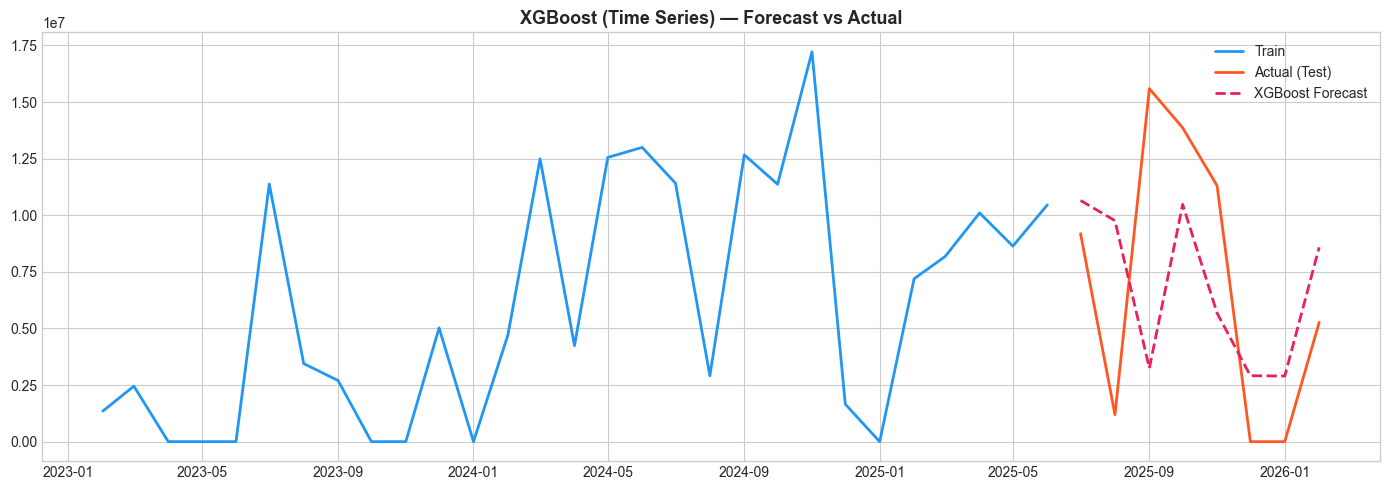

In [46]:
from sklearn.model_selection import GridSearchCV

# Grid Search for best XGBoost params
param_grid = {
    'n_estimators'  : [100, 200],
    'learning_rate' : [0.05, 0.1],
    'max_depth'     : [3, 5]
}

xgb_base = XGBRegressor(random_state=42, verbosity=0)
grid_search = GridSearchCV(xgb_base, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f'✅ Best XGBoost params: {grid_search.best_params_}')

# Train best model
xgb_model = grid_search.best_estimator_
xgb_pred  = xgb_model.predict(X_test)
xgb_forecast = pd.Series(xgb_pred, index=y_test.index)

# Evaluate
xgb_metrics = evaluate_model(y_test, xgb_forecast, 'XGBoost')
results.append(xgb_metrics)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values, label='Train', color='#2196F3', linewidth=2)
plt.plot(test.index,  test.values,  label='Actual (Test)', color='#FF5722', linewidth=2)
plt.plot(xgb_forecast.index, xgb_forecast.values, label='XGBoost Forecast', color='#E91E63', linewidth=2, linestyle='--')
plt.title('XGBoost (Time Series) — Forecast vs Actual', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('09_xgboost_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

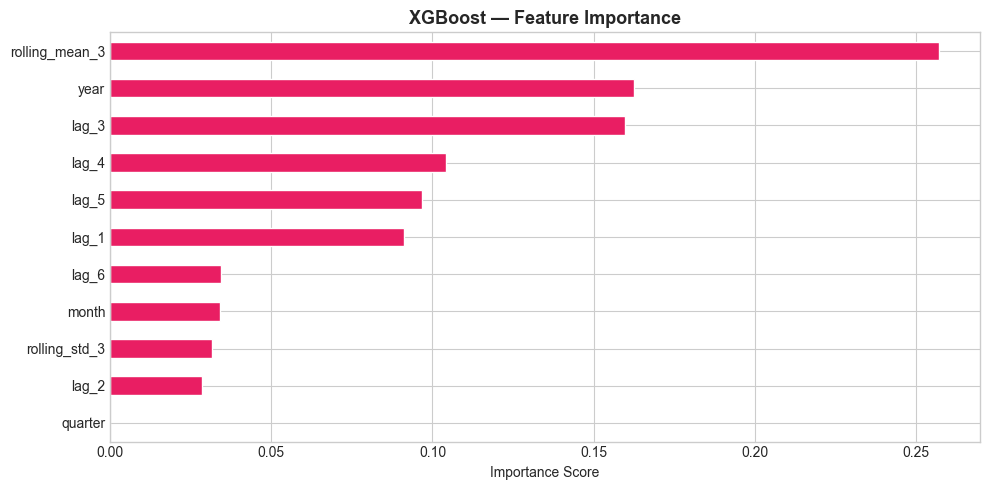

In [47]:
# XGBoost Feature Importance
feat_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='barh', color='#E91E63', edgecolor='white')
plt.title('XGBoost — Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('10_xgboost_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🏆 CELL 17 — Model Comparison

In [48]:
# Build comparison table
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.round(2)
results_df['Rank'] = results_df['RMSE'].rank().astype(int)
results_df = results_df.sort_values('RMSE')

print('\n' + '='*55)
print('  📊 MODEL COMPARISON TABLE')
print('='*55)
print(results_df.to_string())
print('='*55)
print(f'\n🥇 Best model: {results_df.index[0]} (lowest RMSE)')


  📊 MODEL COMPARISON TABLE
               MAE       RMSE   MAPE  Rank
Model                                     
Prophet 5326610.12 5922525.14 143.79     1
XGBoost 5063483.50 6112020.88 158.73     2
SARIMA  5434976.25 6122742.25 133.98     3
ARIMA   5434976.25 6145788.08 134.97     4

🥇 Best model: Prophet (lowest RMSE)


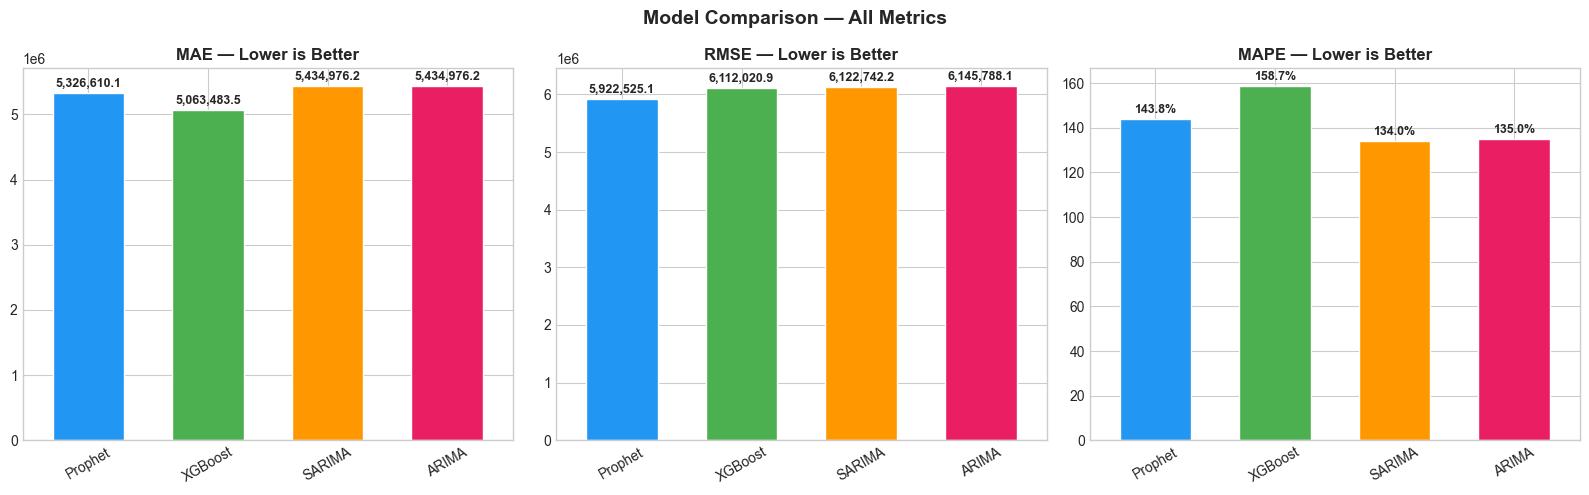

✅ Model comparison saved as 11_model_comparison.png


In [49]:
# Comparison Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, metric in enumerate(['MAE', 'RMSE', 'MAPE']):
    results_df[metric].plot(
        kind='bar', ax=axes[i],
        color=colors[:len(results_df)],
        edgecolor='white', width=0.6
    )
    axes[i].set_title(f'{metric} — Lower is Better', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    unit = '%' if metric == 'MAPE' else ''
    for bar in axes[i].patches:
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.01,
            f'{bar.get_height():,.1f}{unit}',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

plt.suptitle('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('11_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Model comparison saved as 11_model_comparison.png')

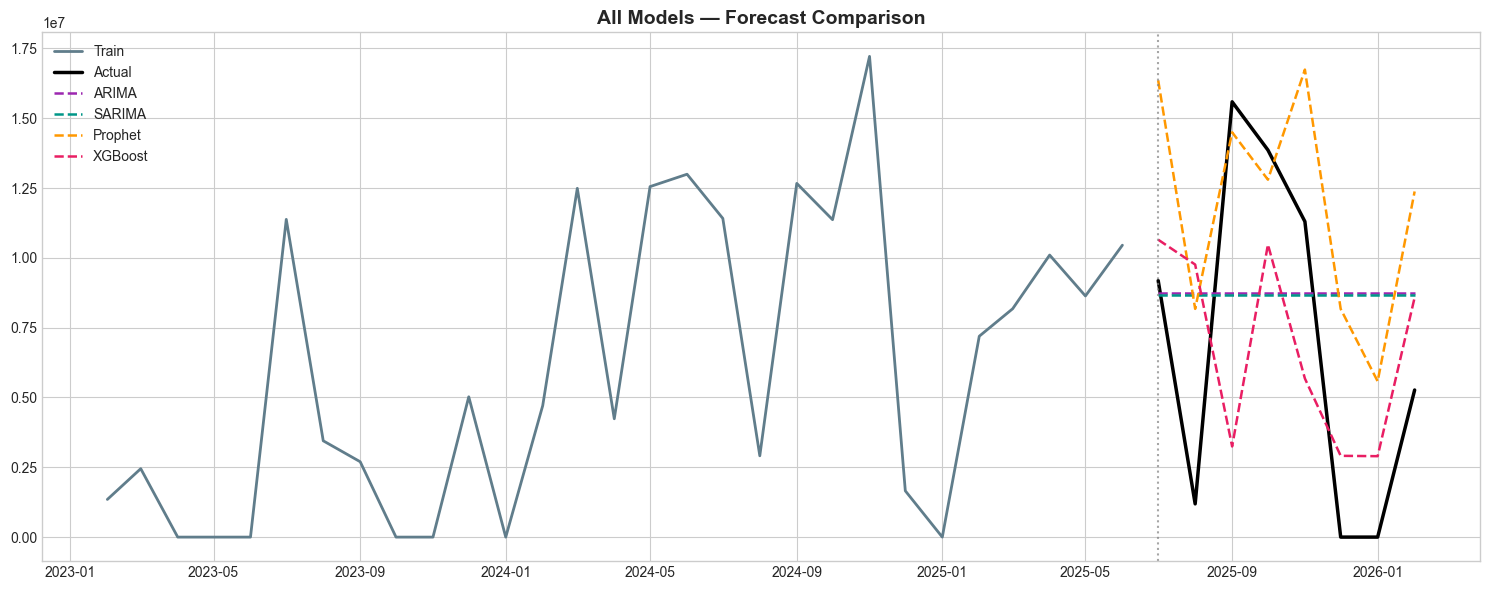

✅ Combined forecast saved as 12_all_forecasts.png


In [50]:
# All forecasts on one plot
plt.figure(figsize=(15, 6))
plt.plot(train.index, train.values, label='Train', color='#607D8B', linewidth=2)
plt.plot(test.index,  test.values,  label='Actual', color='black', linewidth=2.5)
plt.plot(arima_forecast.index,   arima_forecast.values,   label='ARIMA',   color='#9C27B0', linewidth=1.8, linestyle='--')
plt.plot(sarima_forecast.index,  sarima_forecast.values,  label='SARIMA',  color='#009688', linewidth=1.8, linestyle='--')
plt.plot(prophet_forecast.index, prophet_forecast.values, label='Prophet', color='#FF9800', linewidth=1.8, linestyle='--')
plt.plot(xgb_forecast.index,     xgb_forecast.values,     label='XGBoost', color='#E91E63', linewidth=1.8, linestyle='--')
plt.axvline(x=test.index[0], color='gray', linestyle=':', alpha=0.7)
plt.title('All Models — Forecast Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('12_all_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Combined forecast saved as 12_all_forecasts.png')

---
## 🔮 CELL 18 — Future Forecast (Next 6 Months) with Best Model

06:35:42 - cmdstanpy - INFO - Chain [1] start processing


🥇 Using best model: Prophet


06:35:42 - cmdstanpy - INFO - Chain [1] done processing


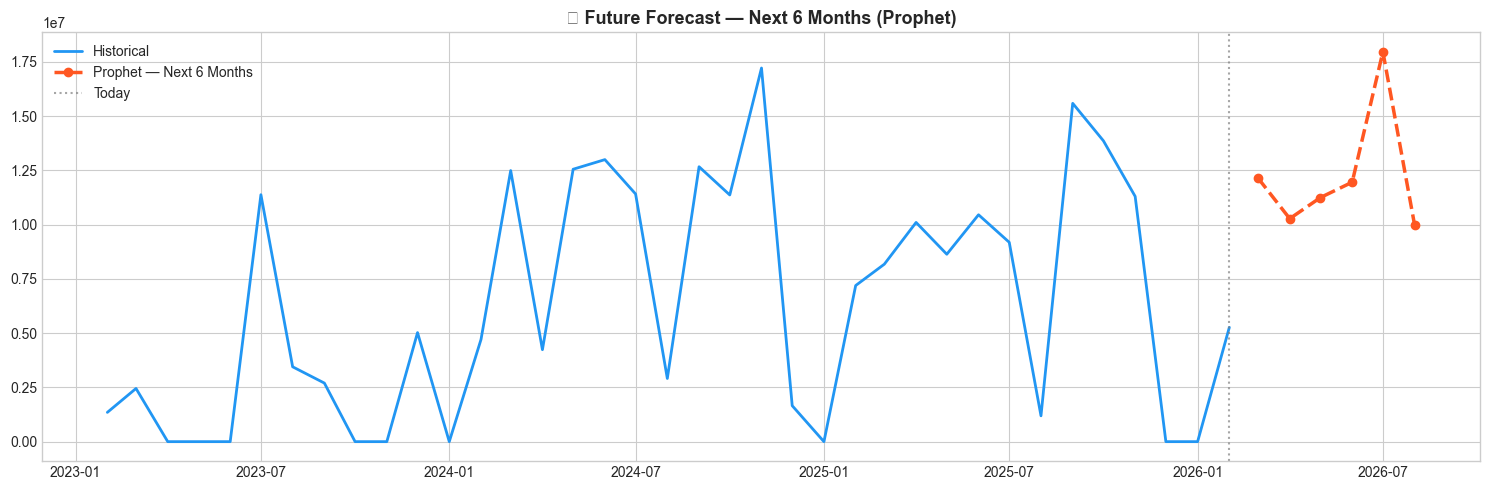


📅 Forecasted Monthly Views:
   March 2026     :   12,145,652 views
   April 2026     :   10,275,550 views
   May 2026       :   11,248,070 views
   June 2026      :   11,955,315 views
   July 2026      :   17,962,789 views
   August 2026    :    9,973,193 views


In [51]:
best_model_name = results_df.index[0]
print(f'🥇 Using best model: {best_model_name}')

future_periods = 6
last_date = ts.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=future_periods, freq='MS')

if best_model_name == 'ARIMA':
    final_model = ARIMA(ts, order=(p, d, q)).fit()
    future_vals = final_model.forecast(steps=future_periods)

elif best_model_name == 'SARIMA':
    final_model = SARIMAX(ts, order=auto_sarima.order,
                          seasonal_order=auto_sarima.seasonal_order,
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False)
    future_vals = final_model.forecast(steps=future_periods)

elif best_model_name == 'Prophet':
    full_prophet_df = pd.DataFrame({'ds': ts.index, 'y': ts.values})
    final_prophet   = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                               daily_seasonality=False, seasonality_mode='additive')
    final_prophet.fit(full_prophet_df)
    future_df    = final_prophet.make_future_dataframe(periods=future_periods, freq='MS')
    prophet_full = final_prophet.predict(future_df)
    future_vals  = prophet_full['yhat'].iloc[-future_periods:].values

else:  # XGBoost
    df_full_features = create_lag_features(ts, n_lags=n_lags)
    X_full = df_full_features.drop(columns=['y'])
    y_full = df_full_features['y']
    xgb_final = XGBRegressor(**grid_search.best_params_, random_state=42, verbosity=0)
    xgb_final.fit(X_full, y_full)
    # Iterative forecasting
    history = list(ts.values)
    future_vals = []
    for _ in range(future_periods):
        row = [history[-i] for i in range(1, n_lags + 1)]
        next_dt = pd.Timestamp(future_dates[len(future_vals)])
        row += [next_dt.month, next_dt.quarter, next_dt.year]
        roll3 = np.mean(history[-3:])
        std3  = np.std(history[-3:])
        row  += [roll3, std3]
        pred = xgb_final.predict(np.array(row).reshape(1, -1))[0]
        future_vals.append(pred)
        history.append(pred)

future_forecast = pd.Series(future_vals, index=future_dates)

# Plot
plt.figure(figsize=(15, 5))
plt.plot(ts.index, ts.values, label='Historical', color='#2196F3', linewidth=2)
plt.plot(future_forecast.index, future_forecast.values,
         label=f'{best_model_name} — Next 6 Months', color='#FF5722',
         linewidth=2.5, linestyle='--', marker='o', markersize=6)
plt.axvline(x=ts.index[-1], color='gray', linestyle=':', alpha=0.7, label='Today')
plt.title(f'📅 Future Forecast — Next 6 Months ({best_model_name})', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('13_future_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📅 Forecasted Monthly Views:')
for date, val in future_forecast.items():
    print(f'   {date.strftime("%B %Y"):15s}: {val:>12,.0f} views')

---
## 💼 CELL 19 — Business Insights Summary

In [52]:
print('='*60)
print('  💼 BUSINESS INSIGHTS SUMMARY')
print('='*60)

print(f'''
1. FORECASTING TARGET
   → Monthly match viewership was chosen as the forecasting
     target because it directly impacts sponsorship value,
     broadcast rights negotiation, and tournament planning.

2. TREND
   → Total views: MIN={ts.min():,.0f} | MAX={ts.max():,.0f} | MEAN={ts.mean():,.0f}
   → The decomposition reveals the underlying growth trend
     and seasonal patterns across the year.

3. MODEL PERFORMANCE
''')
print(results_df[['MAE', 'RMSE', 'MAPE']].to_string())

print(f'''
4. BEST MODEL
   → {results_df.index[0]} achieved the lowest RMSE ({results_df['RMSE'].iloc[0]:,.0f})
     and MAPE ({results_df['MAPE'].iloc[0]:.1f}%).

5. RECOMMENDATIONS
   → Sponsors should increase investment in peak viewership months
   → Tournament organizers can use forecasts to schedule high-profile
     matches during peak engagement periods
   → Broadcasters can plan ad inventory based on forecasted views
''')
print('='*60)

  💼 BUSINESS INSIGHTS SUMMARY

1. FORECASTING TARGET
   → Monthly match viewership was chosen as the forecasting
     target because it directly impacts sponsorship value,
     broadcast rights negotiation, and tournament planning.

2. TREND
   → Total views: MIN=0 | MAX=17,216,601 | MEAN=6,257,466
   → The decomposition reveals the underlying growth trend
     and seasonal patterns across the year.

3. MODEL PERFORMANCE

               MAE       RMSE   MAPE
Model                               
Prophet 5326610.12 5922525.14 143.79
XGBoost 5063483.50 6112020.88 158.73
SARIMA  5434976.25 6122742.25 133.98
ARIMA   5434976.25 6145788.08 134.97

4. BEST MODEL
   → Prophet achieved the lowest RMSE (5,922,525)
     and MAPE (143.8%).

5. RECOMMENDATIONS
   → Sponsors should increase investment in peak viewership months
   → Tournament organizers can use forecasts to schedule high-profile
     matches during peak engagement periods
   → Broadcasters can plan ad inventory based on forecasted vi

---
## ✅ CELL 20 — Close Connection

In [53]:
conn.close()
print('✅ Database connection closed.')
print('🎾 Time Series analysis complete! All plots saved.')
print('\nFiles generated:')
saved_files = [
    '01_exploratory_plots.png',
    '02_decomposition.png',
    '03_acf_pacf.png',
    '04_train_test_split.png',
    '05_arima_forecast.png',
    '06_sarima_forecast.png',
    '07_prophet_forecast.png',
    '08_prophet_components.png',
    '09_xgboost_forecast.png',
    '10_xgboost_feature_importance.png',
    '11_model_comparison.png',
    '12_all_forecasts.png',
    '13_future_forecast.png',
]
for f in saved_files:
    print(f'   ✅ {f}')

✅ Database connection closed.
🎾 Time Series analysis complete! All plots saved.

Files generated:
   ✅ 01_exploratory_plots.png
   ✅ 02_decomposition.png
   ✅ 03_acf_pacf.png
   ✅ 04_train_test_split.png
   ✅ 05_arima_forecast.png
   ✅ 06_sarima_forecast.png
   ✅ 07_prophet_forecast.png
   ✅ 08_prophet_components.png
   ✅ 09_xgboost_forecast.png
   ✅ 10_xgboost_feature_importance.png
   ✅ 11_model_comparison.png
   ✅ 12_all_forecasts.png
   ✅ 13_future_forecast.png
